# ERP Enhancement Benchmark: DSS vs Standard Methods on the Runabout Dataset

**Goal.** Provide a reviewer-ready evaluation of DSS (`AverageBias`) for
ERP extraction, comparing it against standard methods on the ds003620
auditory oddball dataset (Liebherr et al., 2021).

## Comparators

| Tag | Pipeline | Spatial filter? | What it tests |
|-----|----------|-----------------|---------------|
| **C0** | Baseline | No | Floor — does *any* spatial filter help? |
| **C1** | Paper pipeline (ICA + ICLabel) | Yes (general) | Traditional cleaning via ICA decomposition |
| **C2** | DSS (AverageBias) | Yes (targeted) | Trial-reproducibility maximisation — our proposed method |

## Evaluation framework

### Anti-circularity design
- **Training set**: Odd-numbered trials → fit spatial filters (DSS)
- **Training set**: Odd-numbered trials → fit spatial filters (DSS)
- **Null control**: Shuffle condition labels → DSS should not create a spurious effect

### Endpoint metrics (computed on test set only)

| Metric | What it shows |
|--------|--------------|
| **Hedges' g** | Effect size of deviant−standard contrast (P300 window) |
| **Peak latency** | Timing stability across pipelines |
| **Morphology r** | Waveform shape preservation |
| **Split-half reliability** | Measurement consistency |
| **Single-trial AUC** | Practical decoding utility |

### QA levels

| Level | Focus | Diagnostics |
|-------|-------|-------------|
| **A** | Component | Eigenvalue curve, topographies, time courses |
| **B** | Signal | Pre/post PSD overlay, evoked overlay, difference waves |
| **C** | Endpoint | Hedges' g, peak latency, morphology r, reliability, AUC |

## Output contract (per subject)

```
derivatives/mne-denoise/runabout/{sub}/erp_dss/
    {pipeline}/
        epochs_test.fif       # Processed test-set epochs
        evoked.fif            # Test-set grand average
        metrics.tsv           # One-row TSV with all endpoint metrics
        model.json            # Pipeline parameters + fit metadata
    qc_figures/
        qa_level_a.png        # Component diagnostics
        qa_level_b.png        # Signal diagnostics
        qa_level_c.png        # Endpoint summary
```

## References
- de Cheveigné & Simon (2008). *Denoising based on spatial filtering.* J Neurosci Methods.
- Liebherr et al. (2021). *EEG and behavioral correlates...* Sci Rep.


## 1 — Configuration

In [1]:
# ── Run-mode toggle ──────────────────────────────────────────────────────────
SMOKE = False                      # True → 1 subject; False → all subjects

# ── Dataset ──────────────────────────────────────────────────────────────────
DATASET_ID = "ds003620"
DATASET_VERSION = "1.1.1"
LINE_FREQ = 50.0                   # Australian mains frequency (Hz)

# ── Preprocessing constants (full Tabi/Liebherr pipeline) ────────────────────
RESAMPLE_FREQ = 250
HP_FREQ = 0.5                     # High-pass before artifact cleaning
LP_FREQ = 40.0                    # Low-pass after artifact cleaning
ASR_CUTOFF = 10                   # ASR burst criterion (SD)
ICA_THRESHOLD = 0.89              # ICLabel threshold for eye/heart components
EPOCH_TMIN = -0.2                 # seconds
EPOCH_TMAX = 0.8                  # seconds
REJECT_UV = 125e-6                # 125 µV peak-to-peak rejection
STIMTRAK_LAG_S = 0.200            # StimTrak delay (seconds)

# ── ERP windows (from literature) ───────────────────────────────────────────
ERP_WINDOWS = {
    "N1":   (0.080, 0.130),
    "MMN":  (0.100, 0.250),
    "P300": (0.250, 0.500),
}
BASELINE_WIN = (-0.200, 0.000)
EVAL_WIN = ERP_WINDOWS["P300"]     # Primary evaluation window

# ── ROI channels ─────────────────────────────────────────────────────────────
PRIMARY_CH = "Cz"                  # N1/P2 vertex site
P300_CH = "Pz"                     # P300 evaluation channel

# ── Pipeline-specific parameters ─────────────────────────────────────────────
DSS_N_COMPONENTS = 5
DSS_N_KEEP = 3

# ── Pipeline display ─────────────────────────────────────────────────────────
PIPE_ORDER = ["C0", "C1", "C2"]
PIPE_LABELS = {
    "C0": "Baseline",
    "C1": "Paper (ICA)",
    "C2": "DSS (AverageBias)",
}
PIPE_COLORS = {
    "C0": "#404040",
    "C1": "#2ca02c",
    "C2": "#d62728",
}

# ── Paths ────────────────────────────────────────────────────────────────────
import pathlib
DATA_ROOT = pathlib.Path(r"d:\mne-denoise\condescending-liskov\data\runabout")
DERIV_ROOT = DATA_ROOT / "derivatives" / "mne-denoise"

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_PERM = 500                       # Null-control permutations

# ── Subject list ─────────────────────────────────────────────────────────────
ALL_SUBJECTS = None

print(f"Mode: {'SMOKE (1 subject)' if SMOKE else 'FULL (all subjects)'}")
print(f"Evaluation window: {EVAL_WIN[0]*1000:.0f}–{EVAL_WIN[1]*1000:.0f} ms (P300)")
print(f"Anti-circularity: train on odd trials, test on even trials")


Mode: FULL (all subjects)
Evaluation window: 250–500 ms (P300)
Anti-circularity: train on odd trials, test on even trials


## 2 — Imports

In [2]:
import json
import warnings
import time as _time
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import welch as sp_welch

from mne.preprocessing import ICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from mne_denoise.dss import DSS, AverageBias
from mne_denoise.zapline import ZapLine

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("WARNING")

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 11,
    "figure.facecolor": "white",
})

print(f"MNE version: {mne.__version__}")
print(f"NumPy version: {np.__version__}")


MNE version: 1.11.0
NumPy version: 2.4.2


## 3 — Data Discovery

Discover available subjects from the local copy of the Runabout dataset.


In [3]:
# Data is already downloaded — discover subjects directly
ds_path = DATA_ROOT
sub_dirs = sorted([d.name for d in ds_path.iterdir()
                   if d.is_dir() and d.name.startswith("sub-")])

if SMOKE:
    ALL_SUBJECTS = sub_dirs[:1]
else:
    ALL_SUBJECTS = sub_dirs[:2]   # Limit for initial run

print(f"Found {len(sub_dirs)} subjects; using {len(ALL_SUBJECTS)}: {ALL_SUBJECTS}")


Found 44 subjects; using 2: ['sub-01', 'sub-02']


## 4 — Full Preprocessing Pipeline

Replicates the Liebherr et al. (2021) / Tabi et al. (2020) pipeline:

1. Resample to 250 Hz
2. Pick EEG + reintroduce FCz
3. Re-reference to linked mastoids (TP9/TP10)
4. High-pass filter at 0.5 Hz (FIR)
5. **ZapLine+ for line noise removal** (fixed for all pipelines)
6. Bad channel detection (flatline + high variance)
7. Low-pass filter at 40 Hz (FIR)
8. ICA (extended infomax) + automatic component rejection
9. Channel interpolation
10. Epoching (−200 to 800 ms, baseline −200 to 0 ms)
11. Artifact rejection (125 µV peak-to-peak)

> **Design note:** Line noise removal (step 5) is **fixed to ZapLine+** for
> all comparators (C0–C2).  The variable under test is the ERP spatial
> filter applied *after* standard preprocessing.


In [4]:
ORIG_SFREQ = 500.0   # Native BrainVision sampling rate for ds003620

def _parse_trial_type(tt):
    """Parse a trigger_corrected trial_type string into (tone, task, condition)."""
    tone = "deviant" if tt.startswith("t_") else "standard"
    task  = "ignore" if "dontcount" in tt.lower() else "count"
    for cond in ("lab", "oval", "campus"):
        if f"_{cond}" in tt:
            return tone, task, cond
    return tone, task, "unknown"


def full_preprocess(sub, ds_path):
    """Full preprocessing pipeline for one subject.

    Returns
    -------
    epochs : mne.Epochs
        Cleaned, epoched data ready for ERP spatial filtering.
    raw_clean : mne.io.Raw
        Cleaned continuous data (post-ICA, pre-epoching).
    ica_obj : mne.preprocessing.ICA
        The fitted ICA object (for C1 pipeline replication).
    preproc_info : dict
        Preprocessing metadata.
    """
    # ── Load ─────────────────────────────────────────────────────────────
    eeg_dir = ds_path / sub / "eeg"
    vhdr_files = sorted(eeg_dir.glob("*.vhdr"))
    if not vhdr_files:
        raise FileNotFoundError(f"No .vhdr file for {sub}")
    raw = mne.io.read_raw_brainvision(str(vhdr_files[0]), preload=True,
                                       verbose=False)

    # Fix encoding
    mapping = {}
    for ch in raw.ch_names:
        cleaned = ch.encode("latin-1", errors="replace").decode("utf-8", errors="replace")
        if cleaned != ch:
            mapping[ch] = cleaned
    if mapping:
        raw.rename_channels(mapping)

    # ── Step 1: Resample ─────────────────────────────────────────────────
    raw.resample(RESAMPLE_FREQ, verbose=False)
    sfreq = raw.info["sfreq"]

    # ── Step 2: Pick EEG + FCz ───────────────────────────────────────────
    raw.pick_types(eeg=True, verbose=False)
    if "FCz" not in raw.ch_names:
        raw.add_reference_channels("FCz")
    raw.set_montage("standard_1020", on_missing="warn")

    # ── Step 3: Re-reference to linked mastoids ──────────────────────────
    mastoids = [ch for ch in ["TP9", "TP10"] if ch in raw.ch_names]
    if len(mastoids) == 2:
        raw.set_eeg_reference(mastoids, verbose=False)
        raw.drop_channels(mastoids)
    else:
        raw.set_eeg_reference("average", verbose=False)

    # ── Step 4: High-pass filter ─────────────────────────────────────────
    raw.filter(l_freq=HP_FREQ, h_freq=None, method="fir",
               fir_design="firwin", verbose=False)

    # ── Step 5: ZapLine+ for line noise ──────────────────────────────────
    zap = ZapLine(sfreq=sfreq, line_freq=LINE_FREQ,
                  n_remove="auto", n_harmonics=3)
    raw = zap.fit_transform(raw)
    n_zap_removed = getattr(zap, "n_removed_", None)

    # ── Step 6: Bad channel detection ────────────────────────────────────
    ch_data = raw.get_data()
    ch_var = np.var(ch_data, axis=1)
    median_var = np.median(ch_var)
    bad_chs = []
    for ci, ch_name in enumerate(raw.ch_names):
        if ch_var[ci] < median_var * 0.01:      # Flatline
            bad_chs.append(ch_name)
        elif ch_var[ci] > median_var * 50:      # Excessive noise
            bad_chs.append(ch_name)
    raw.info["bads"] = bad_chs

    # ── Step 7: Low-pass filter ──────────────────────────────────────────
    raw.filter(l_freq=None, h_freq=LP_FREQ, method="fir",
               fir_design="firwin", verbose=False)

    # ── Step 8: ICA ──────────────────────────────────────────────────────
    n_good = raw.info["nchan"] - len(bad_chs)
    n_ica = min(20, n_good - 1)
    ica = ICA(n_components=n_ica, method="infomax",
              fit_params=dict(extended=True),
              random_state=RANDOM_STATE, max_iter=1000)
    ica.fit(raw, picks="eeg", verbose=False)

    # Automatic component rejection (EOG + ECG proxy)
    eog_idx = []
    for proxy_ch in ["Fp1", "Fp2"]:
        if proxy_ch in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name=proxy_ch,
                                        threshold=3.0, verbose=False)
            eog_idx.extend(idx)
    eog_idx = list(set(eog_idx))
    try:
        ecg_idx, _ = ica.find_bads_ecg(raw, method="correlation",
                                         threshold=0.25, verbose=False)
    except Exception:
        ecg_idx = []
    ica.exclude = list(set(eog_idx + ecg_idx))

    raw_clean = ica.apply(raw.copy(), verbose=False)

    # ── Step 9: Interpolate ──────────────────────────────────────────────
    if bad_chs:
        raw_clean.interpolate_bads(verbose=False)

    # ── Step 10: Epoching (trigger-corrected events) ─────────────────────
    # Read trigger-corrected events with rich trial_type labels
    trig_dir = ds_path / "derivatives" / "trigger_corrected" / sub / "eeg"
    evt_files = sorted(trig_dir.glob("*_events.tsv"))
    if not evt_files:
        raise FileNotFoundError(
            f"No trigger_corrected events for {sub}. "
            "Run the line-noise benchmark first or download derivatives."
        )

    tc_df = pd.read_csv(evt_files[0], sep="\t")
    tc_df = tc_df[tc_df["trial_type"] != "empty"].reset_index(drop=True)

    # Convert onsets: original samples (500 Hz) → resampled samples (250 Hz)
    tc_df["sample_rs"] = np.round(
        tc_df["onset"].values * (sfreq / ORIG_SFREQ)
    ).astype(int)

    # Parse trial_type → tone / task / condition
    parsed = [_parse_trial_type(tt) for tt in tc_df["trial_type"]]
    tc_df["tone"]      = [p[0] for p in parsed]
    tc_df["task"]      = [p[1] for p in parsed]
    tc_df["condition"] = [p[2] for p in parsed]

    # Build event_id mapping (deterministic order)
    unique_types = sorted(tc_df["trial_type"].unique())
    event_id = {tt: i + 1 for i, tt in enumerate(unique_types)}

    # Build MNE events array  [sample, 0, code]
    events_arr = np.column_stack([
        tc_df["sample_rs"].values,
        np.zeros(len(tc_df), dtype=int),
        np.array([event_id[tt] for tt in tc_df["trial_type"]])
    ])

    # Remove events outside recording bounds
    max_sample = raw_clean.n_times - 1
    valid = (events_arr[:, 0] >= 0) & (events_arr[:, 0] < max_sample)
    events_arr = events_arr[valid]
    tc_df = tc_df.iloc[np.where(valid)[0]].reset_index(drop=True)

    epochs = mne.Epochs(
        raw_clean, events_arr, event_id=event_id,
        tmin=EPOCH_TMIN, tmax=EPOCH_TMAX,
        baseline=(EPOCH_TMIN, 0),
        preload=True, verbose=False,
    )

    # ── Step 11: Artifact rejection ──────────────────────────────────────
    n_before = len(epochs)
    epochs.drop_bad(reject=dict(eeg=REJECT_UV), verbose=False)
    n_after = len(epochs)

    # ── Build metadata from surviving epochs ─────────────────────────────
    kept = epochs.selection           # indices into events_arr of surviving epochs
    meta_df = tc_df.iloc[kept][["tone", "task", "condition", "trial_type"]].reset_index(drop=True)
    epochs.metadata = meta_df

    preproc_info = {
        "n_channels": raw_clean.info["nchan"],
        "sfreq": sfreq,
        "bad_channels": bad_chs,
        "ica_excluded": [int(x) for x in ica.exclude],
        "n_ica_components": int(ica.n_components_),
        "zapline_removed": n_zap_removed,
        "n_epochs_before_reject": int(n_before),
        "n_epochs_after_reject": int(n_after),
        "reject_rate": float((1 - n_after / max(n_before, 1)) * 100),
        "n_deviant": int((meta_df["tone"] == "deviant").sum()),
        "n_standard": int((meta_df["tone"] == "standard").sum()),
    }

    return epochs, raw_clean, ica, preproc_info


# Quick test
_test_ep, _test_raw, _test_ica, _test_info = full_preprocess(
    ALL_SUBJECTS[0], DATA_ROOT)
print(f"Test: {_test_info['n_epochs_after_reject']} epochs, "
      f"{_test_info['n_channels']} ch, "
      f"reject rate = {_test_info['reject_rate']:.1f}%")
print(f"  Deviant: {_test_info['n_deviant']},  Standard: {_test_info['n_standard']}")
print(f"ICA excluded: {_test_info['ica_excluded']}")
print(f"Metadata columns: {list(_test_ep.metadata.columns)}")
print(f"\nCondition counts:")
print(_test_ep.metadata.groupby(["tone", "task", "condition"]).size())
del _test_ep, _test_raw, _test_ica, _test_info


Test: 2110 epochs, 31 ch, reject rate = 53.1%
  Deviant: 427,  Standard: 1683
ICA excluded: [0, 3, 5]
Metadata columns: ['tone', 'task', 'condition', 'trial_type']

Condition counts:
tone      task    condition
deviant   count   campus        31
                  lab          126
                  oval          42
          ignore  campus        33
                  lab           86
                  oval         109
standard  count   campus       131
                  lab          430
                  oval         148
          ignore  campus       119
                  lab          446
                  oval         409
dtype: int64


## 5 — Endpoint Metric Functions

All metrics are designed for **anti-circular** evaluation: they take processed
*test-set* epochs as input.  Spatial filters are never fitted on the data they
are evaluated on.


In [18]:
def hedges_g(x, y):
    """Hedges' g (bias-corrected Cohen's d)."""
    n1, n2 = len(x), len(y)
    if n1 < 15 or n2 < 15:  # Require minimum trials
        return np.nan
    s_pooled = np.sqrt(((n1 - 1) * np.var(x, ddof=1) +
                        (n2 - 1) * np.var(y, ddof=1)) / (n1 + n2 - 2))
    if s_pooled < 1e-15:
        return np.nan
    d = (np.mean(x) - np.mean(y)) / s_pooled
    correction = 1 - 3 / (4 * (n1 + n2) - 9)
    return d * correction


def peak_latency_ms(evoked_data, times_s, win, mode="pos"):
    """Peak latency (ms) via Fractional Area Latency (50% AUC) within a time window.

    mode: 'pos' for P300, 'neg' for N1/MMN, 'abs' for largest absolute.
    """
    mask = (times_s >= win[0]) & (times_s <= win[1])
    if not mask.any():
        return np.nan
        
    segment = evoked_data[mask]
    if mode == "pos":
        # Only consider positive values for area
        val = np.maximum(segment, 0)
    elif mode == "neg":
        # Only consider negative values
        val = np.maximum(-segment, 0)
    else:
        val = np.abs(segment)
        
    cum_area = np.cumsum(val)
    if cum_area[-1] == 0:
        return np.nan
        
    half_point = cum_area[-1] / 2.0
    idx_50 = np.searchsorted(cum_area, half_point)
    return times_s[mask][idx_50] * 1000


def morphology_corr(ev_pipe, ev_base, times_s, excl_win):
    """Pearson r between pipeline and baseline waveforms OUTSIDE eval window."""
    mask = (times_s < excl_win[0]) | (times_s > excl_win[1])
    if mask.sum() < 3:
        return np.nan
    r, _ = stats.pearsonr(ev_pipe[mask], ev_base[mask])
    return r


def morphology_nrmse(ev_pipe, ev_base, times_s, excl_win):
    """Normalized Root Mean Square Error vs baseline OUTSIDE eval window.
    
    Protects against Pearson r's scale invariance (e.g. rank collapse hiding behind high correlation).
    """
    mask = (times_s < excl_win[0]) | (times_s > excl_win[1])
    if mask.sum() < 3:
        return np.nan
    pipe_seg = ev_pipe[mask]
    base_seg = ev_base[mask]
    
    rmse = np.sqrt(np.mean((pipe_seg - base_seg)**2))
    # Normalize by the interquartile range of the baseline segment to be robust to outliers
    iqr = np.percentile(base_seg, 75) - np.percentile(base_seg, 25)
    return rmse / iqr if iqr > 0 else np.nan


def split_half_reliability(epoch_data_1ch):
    """Spearman-Brown corrected split-half reliability.

    Parameters
    ----------
    epoch_data_1ch : array (n_epochs, n_times)
    """
    ev_even = epoch_data_1ch[0::2].mean(axis=0)
    ev_odd = epoch_data_1ch[1::2].mean(axis=0)
    r, _ = stats.pearsonr(ev_even, ev_odd)
    sb_r = (2 * r) / (1 + abs(r))
    return sb_r


def single_trial_auc(epochs_data_1ch, times, time_window,
                     dev_mask, std_mask, random_state=42):
    """Decode deviant vs standard from single-trial mean amplitude.

    Returns mean ROC-AUC from stratified k-fold CV.
    """
    t_mask = (times >= time_window[0]) & (times <= time_window[1])
    features = epochs_data_1ch[:, t_mask].mean(axis=1).reshape(-1, 1)

    labels = np.full(len(epochs_data_1ch), -1)
    labels[dev_mask] = 1
    labels[std_mask] = 0
    valid = labels >= 0
    X, y = features[valid], labels[valid].astype(int)

    if len(np.unique(y)) < 2 or X.shape[0] < 10:
        return np.nan

    clf = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    n_min = min(np.bincount(y))
    cv = StratifiedKFold(n_splits=min(5, n_min), shuffle=True,
                         random_state=random_state)
    try:
        scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
        return scores.mean()
    except Exception:
        return np.nan


def compute_all_erp_metrics(epochs_test, evoked_test, evoked_baseline,
                            ch_pz_idx, ch_cz_idx, times,
                            dev_mask, std_mask, eval_win=EVAL_WIN):
    """Compute all 5 endpoint metrics for one pipeline.

    Parameters
    ----------
    epochs_test : array (n_epochs, n_channels, n_times) or Epochs
    evoked_test : Evoked
    evoked_baseline : Evoked (C0 reference)
    ch_pz_idx, ch_cz_idx : int
    times : array
    dev_mask, std_mask : bool arrays
    eval_win : tuple

    Returns
    -------
    dict of metrics
    """
    if hasattr(epochs_test, "get_data"):
        data = epochs_test.get_data()
    else:
        data = epochs_test

    pz_data = data[:, ch_pz_idx, :] * 1e6  # µV

    # 1. Hedges' g
    t_mask = (times >= eval_win[0]) & (times <= eval_win[1])
    amp_dev = pz_data[dev_mask][:, t_mask].mean(axis=1) if dev_mask.any() else np.array([])
    amp_std = pz_data[std_mask][:, t_mask].mean(axis=1) if std_mask.any() else np.array([])
    g = hedges_g(amp_dev, amp_std) if len(amp_dev) >= 2 and len(amp_std) >= 2 else np.nan

    # 2. Peak latency (positive peak for P300 at Pz)
    ev_pz = evoked_test.data[ch_pz_idx] * 1e6
    plat = peak_latency_ms(ev_pz, evoked_test.times, eval_win, mode="pos")

    # 3. Morphology correlation vs baseline (at Cz, outside eval window)
    ev_cz = evoked_test.data[ch_cz_idx] * 1e6
    base_cz = evoked_baseline.data[ch_cz_idx] * 1e6
    mr = morphology_corr(ev_cz, base_cz, evoked_test.times, eval_win)
    nrmse = morphology_nrmse(ev_cz, base_cz, evoked_test.times, eval_win)

    # 4. Split-half reliability (at Pz)
    shr = split_half_reliability(pz_data)

    # 5. Single-trial AUC
    auc = single_trial_auc(pz_data, times, eval_win, dev_mask, std_mask)

    return {
        "hedges_g": g,
        "peak_lat_ms": plat,
        "morph_r": mr,
        "morph_nrmse": nrmse,
        "split_half_r": shr,
        "auc": auc,
    }


print("✓ Metric functions defined")


✓ Metric functions defined


## 6 — Pipeline Application Functions

Each comparator is implemented as a function that takes training and test
epochs, applies its spatial filter, and returns processed test epochs.

- **C0 (Baseline):** No-op — test epochs are returned as-is.
- **C1 (ICA):** Reapply the ICA solution from preprocessing to test epochs.
- **C2 (DSS):** Fit `AverageBias` on training epochs, apply to test epochs (keep top-k).


In [19]:
def apply_c0_baseline(epochs_train, epochs_test, **kwargs):
    """C0: Baseline — no spatial filter."""
    return epochs_test.copy(), {"pipeline": "C0_baseline"}


def apply_c1_ica(epochs_train, epochs_test, ica_obj=None, **kwargs):
    """C1: Paper pipeline (ICA).

    The ICA was already fitted during preprocessing. Here we re-apply
    the exclusion to test epochs (in case they weren't already cleaned).
    """
    if ica_obj is None:
        return epochs_test.copy(), {"pipeline": "C1_ica", "error": "no ICA object"}
    epochs_out = ica_obj.apply(epochs_test.copy(), verbose=False)
    info = {
        "pipeline": "C1_ica",
        "n_components": int(ica_obj.n_components_),
        "excluded": [int(x) for x in ica_obj.exclude],
    }
    return epochs_out, info


def apply_c2_dss(epochs_train, epochs_test,
                 n_components=DSS_N_COMPONENTS, n_keep=DSS_N_KEEP, **kwargs):
    """C2: DSS (AverageBias) — trial-reproducibility maximisation.

    Fit on training epochs, transform test epochs, keep top-k, reconstruct.
    """
    bias = AverageBias(axis="epochs")
    dss = DSS(bias=bias, n_components=n_components, return_type="sources")
    dss.fit(epochs_train)

    # Transform test → sources → keep top-k → reconstruct
    sources_test = dss.transform(epochs_test)
    sources_kept = sources_test.copy()
    sources_kept[:, n_keep:, :] = 0
    data_recon = dss.inverse_transform(sources_kept)

    # Handle shape
    if data_recon.ndim == 2:
        data_recon = data_recon[np.newaxis, ...]
    elif data_recon.ndim == 3 and data_recon.shape[0] == len(epochs_test.ch_names):
        data_recon = np.transpose(data_recon, (2, 0, 1))

    epochs_out = mne.EpochsArray(
        data_recon, epochs_test.info,
        tmin=epochs_test.tmin, verbose=False,
    )
    if epochs_test.metadata is not None:
        epochs_out.metadata = epochs_test.metadata.copy()

    info = {
        "pipeline": "C2_dss",
        "n_components": n_components,
        "n_keep": n_keep,
        "eigenvalues": dss.eigenvalues_.tolist() if hasattr(dss, "eigenvalues_") else None,
    }
    return epochs_out, info


PIPELINES = {
    "C0": apply_c0_baseline,
    "C1": apply_c1_ica,
    "C2": apply_c2_dss,
}

print("✓ Pipeline functions defined")


✓ Pipeline functions defined


## 7 — Per-Subject Processing

`process_subject(sub)` runs the full preprocessing pipeline, splits into
train/test, applies all 4 comparators, computes metrics, and writes
everything to disk.


In [20]:
def process_subject(sub, ds_path=None, deriv_root=DERIV_ROOT):
    """Run the full ERP benchmark pipeline for one subject.

    Parameters
    ----------
    sub : str
    ds_path : Path or None
    deriv_root : Path

    Returns
    -------
    results : dict
        {pipeline_tag: {metrics_dict, pipeline_info}}
    """
    if ds_path is None:
        ds_path = DATA_ROOT

    print(f"\n{'='*60}")
    print(f"  {sub} — ERP DSS Benchmark")
    print(f"{'='*60}")

    # ── Full preprocessing ───────────────────────────────────────────────
    epochs, raw_clean, ica_obj, preproc_info = full_preprocess(sub, ds_path)
    print(f"  Preprocessing: {preproc_info['n_epochs_after_reject']} epochs, "
          f"reject rate = {preproc_info['reject_rate']:.1f}%")

    # ── Train/test split (anti-circularity) ──────────────────────────────
    n_ep = len(epochs)
    train_idx = np.arange(0, n_ep, 2)  # Even-indexed = train
    test_idx = np.arange(1, n_ep, 2)   # Odd-indexed = test
    epochs_train = epochs[train_idx]
    epochs_test = epochs[test_idx]
    print(f"  Train/test split: {len(train_idx)} / {len(test_idx)}")

    # ── Condition masks for test set ─────────────────────────────────────
    meta_test = epochs_test.metadata
    if meta_test is not None and "tone" in meta_test.columns:
        test_tone = meta_test["tone"].values
        test_task = meta_test["task"].values
        dev_count_mask = (test_tone == "deviant") & (test_task == "count")
        std_count_mask = (test_tone == "standard") & (test_task == "count")
    else:
        dev_count_mask = np.zeros(len(test_idx), dtype=bool)
        std_count_mask = np.ones(len(test_idx), dtype=bool)
    print(f"  Conditions (test): {dev_count_mask.sum()} dev+count, "
          f"{std_count_mask.sum()} std+count")

    # ── Channel indices ──────────────────────────────────────────────────
    ch_pz = epochs_test.ch_names.index(P300_CH)
    ch_cz = epochs_test.ch_names.index(PRIMARY_CH)
    times = epochs_test.times

    # ── Apply all pipelines ──────────────────────────────────────────────
    results = {}
    pipe_epochs = {}
    pipe_evokeds = {}

    for ptag in PIPE_ORDER:
        print(f"  ── {ptag}: {PIPE_LABELS[ptag]} ... ", end="")
        try:
            ep_out, p_info = PIPELINES[ptag](
                epochs_train, epochs_test, ica_obj=ica_obj,
            )
            pipe_epochs[ptag] = ep_out
            pipe_evokeds[ptag] = ep_out.average()
            results[ptag] = {"info": p_info}
            print("✓")
        except Exception as e:
            print(f"FAILED: {e}")
            pipe_epochs[ptag] = epochs_test.copy()
            pipe_evokeds[ptag] = epochs_test.average()
            results[ptag] = {"info": {"error": str(e)}}

    # ── Compute metrics (all against C0 baseline) ────────────────────────
    ev_baseline = pipe_evokeds["C0"]

    for ptag in PIPE_ORDER:
        ep = pipe_epochs[ptag]
        ev = pipe_evokeds[ptag]

        # For C0, morph_r is 1.0 by definition
        if ptag == "C0":
            m = compute_all_erp_metrics(
                ep, ev, ev, ch_pz, ch_cz, times,
                dev_count_mask, std_count_mask)
            m["morph_r"] = 1.0
        else:
            m = compute_all_erp_metrics(
                ep, ev, ev_baseline, ch_pz, ch_cz, times,
                dev_count_mask, std_count_mask)

        results[ptag]["metrics"] = m
        print(f"  {ptag}: g={m['hedges_g']:.3f}, "
              f"lat={m['peak_lat_ms']:.0f}ms, "
              f"shr={m['split_half_r']:.3f}")

    # ── Save to disk ─────────────────────────────────────────────────────
    def _jsonify(obj):
        """Recursively convert numpy types for JSON serialisation."""
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, list):
            return [_jsonify(v) for v in obj]
        if isinstance(obj, dict):
            return {k: _jsonify(v) for k, v in obj.items()}
        return obj

    for ptag in PIPE_ORDER:
        out_dir = deriv_root / sub / "erp_dss" / ptag
        out_dir.mkdir(parents=True, exist_ok=True)

        # Metrics TSV
        m = results[ptag]["metrics"]
        df = pd.DataFrame([m])
        df.insert(0, "subject", sub)
        df.insert(1, "pipeline", ptag)
        df.to_csv(out_dir / "metrics.tsv", sep="\t", index=False)

        # Model JSON
        info = results[ptag]["info"]
        info_clean = _jsonify(info)
        with open(out_dir / "model.json", "w") as f:
            json.dump(info_clean, f, indent=2)

    # Save preprocessing info
    info_dir = deriv_root / sub / "erp_dss"
    with open(info_dir / "preproc_info.json", "w") as f:
        json.dump(_jsonify(preproc_info), f, indent=2)

    # ── Clean up ─────────────────────────────────────────────────────────
    del epochs, raw_clean, ica_obj, epochs_train, epochs_test
    del pipe_epochs, pipe_evokeds

    return results


print("✓ process_subject() defined")


✓ process_subject() defined


## 8 — Main Processing Loop

In [28]:
all_results = {}
t0 = _time.perf_counter()

for sub in ALL_SUBJECTS:
    all_results[sub] = process_subject(sub)

elapsed = _time.perf_counter() - t0
print(f"\n{'='*60}")
print(f"All subjects processed in {elapsed:.1f} s")
print(f"{'='*60}")



  sub-01 — ERP DSS Benchmark
  Preprocessing: 2110 epochs, reject rate = 53.1%
  Train/test split: 1055 / 1055
  Conditions (test): 102 dev+count, 352 std+count
  ── C0: Baseline ... ✓
  ── C1: Paper (ICA) ... ✓
  ── C2: DSS (AverageBias) ... ✓
  C0: g=0.249, lat=nanms, shr=0.860
  C1: g=0.249, lat=nanms, shr=0.860
  C2: g=0.223, lat=320ms, shr=0.970

  sub-02 — ERP DSS Benchmark
  Preprocessing: 2018 epochs, reject rate = 54.1%
  Train/test split: 1009 / 1009
  Conditions (test): 144 dev+count, 555 std+count
  ── C0: Baseline ... ✓
  ── C1: Paper (ICA) ... ✓
  ── C2: DSS (AverageBias) ... ✓
  C0: g=0.199, lat=452ms, shr=0.950
  C1: g=0.199, lat=452ms, shr=0.950
  C2: g=0.013, lat=256ms, shr=0.942

All subjects processed in 314.6 s


## 9 — Group Aggregation from Disk

Re-read all `metrics.tsv` files.  This section is safe to run after a
kernel restart.


In [29]:
def aggregate_erp_from_disk(deriv_root=DERIV_ROOT, subjects=None):
    """Read all ERP metrics.tsv files into a single DataFrame."""
    frames = []
    if subjects is None:
        subjects = sorted([d.name for d in deriv_root.iterdir()
                           if d.is_dir() and d.name.startswith("sub-")])
    for sub in subjects:
        erp_dir = deriv_root / sub / "erp_dss"
        if not erp_dir.exists():
            continue
        for pipe_dir in sorted(erp_dir.iterdir()):
            tsv = pipe_dir / "metrics.tsv"
            if tsv.exists():
                frames.append(pd.read_csv(tsv, sep="\t"))
    if frames:
        return pd.concat(frames, ignore_index=True)
    return pd.DataFrame()


df_erp = aggregate_erp_from_disk(subjects=ALL_SUBJECTS)
print(f"Aggregated {len(df_erp)} rows from disk")
df_erp


Aggregated 6 rows from disk


,subject,pipeline,hedges_g,peak_lat_ms,morph_r,morph_nrmse,split_half_r,auc
0,sub-01,C0,0.249150,NaN,1.000000,0.000000,0.859678,0.569763
1,sub-01,C1,0.249150,NaN,1.000000,0.001320,0.859678,0.569763
2,sub-01,C2,0.223375,320.0,0.932803,0.693832,0.970499,0.566403
3,sub-02,C0,0.199443,452.0,1.000000,0.000000,0.949699,0.556397
4,sub-02,C1,0.199443,452.0,1.000000,0.000325,0.949699,0.556397
5,sub-02,C2,0.012962,256.0,-0.090860,1.030201,0.942261,0.484747


## 10 — QA Level A: Component-Level Diagnostics

*Does DSS extract the intended signal?*

We recompute DSS on the first subject's training data to show:
1. Eigenvalue/bias-score spectrum
2. Component topographies
3. Component time courses (training-set average ± SEM)


C:\Users\s\AppData\Local\Temp\ipykernel_3948\472298555.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


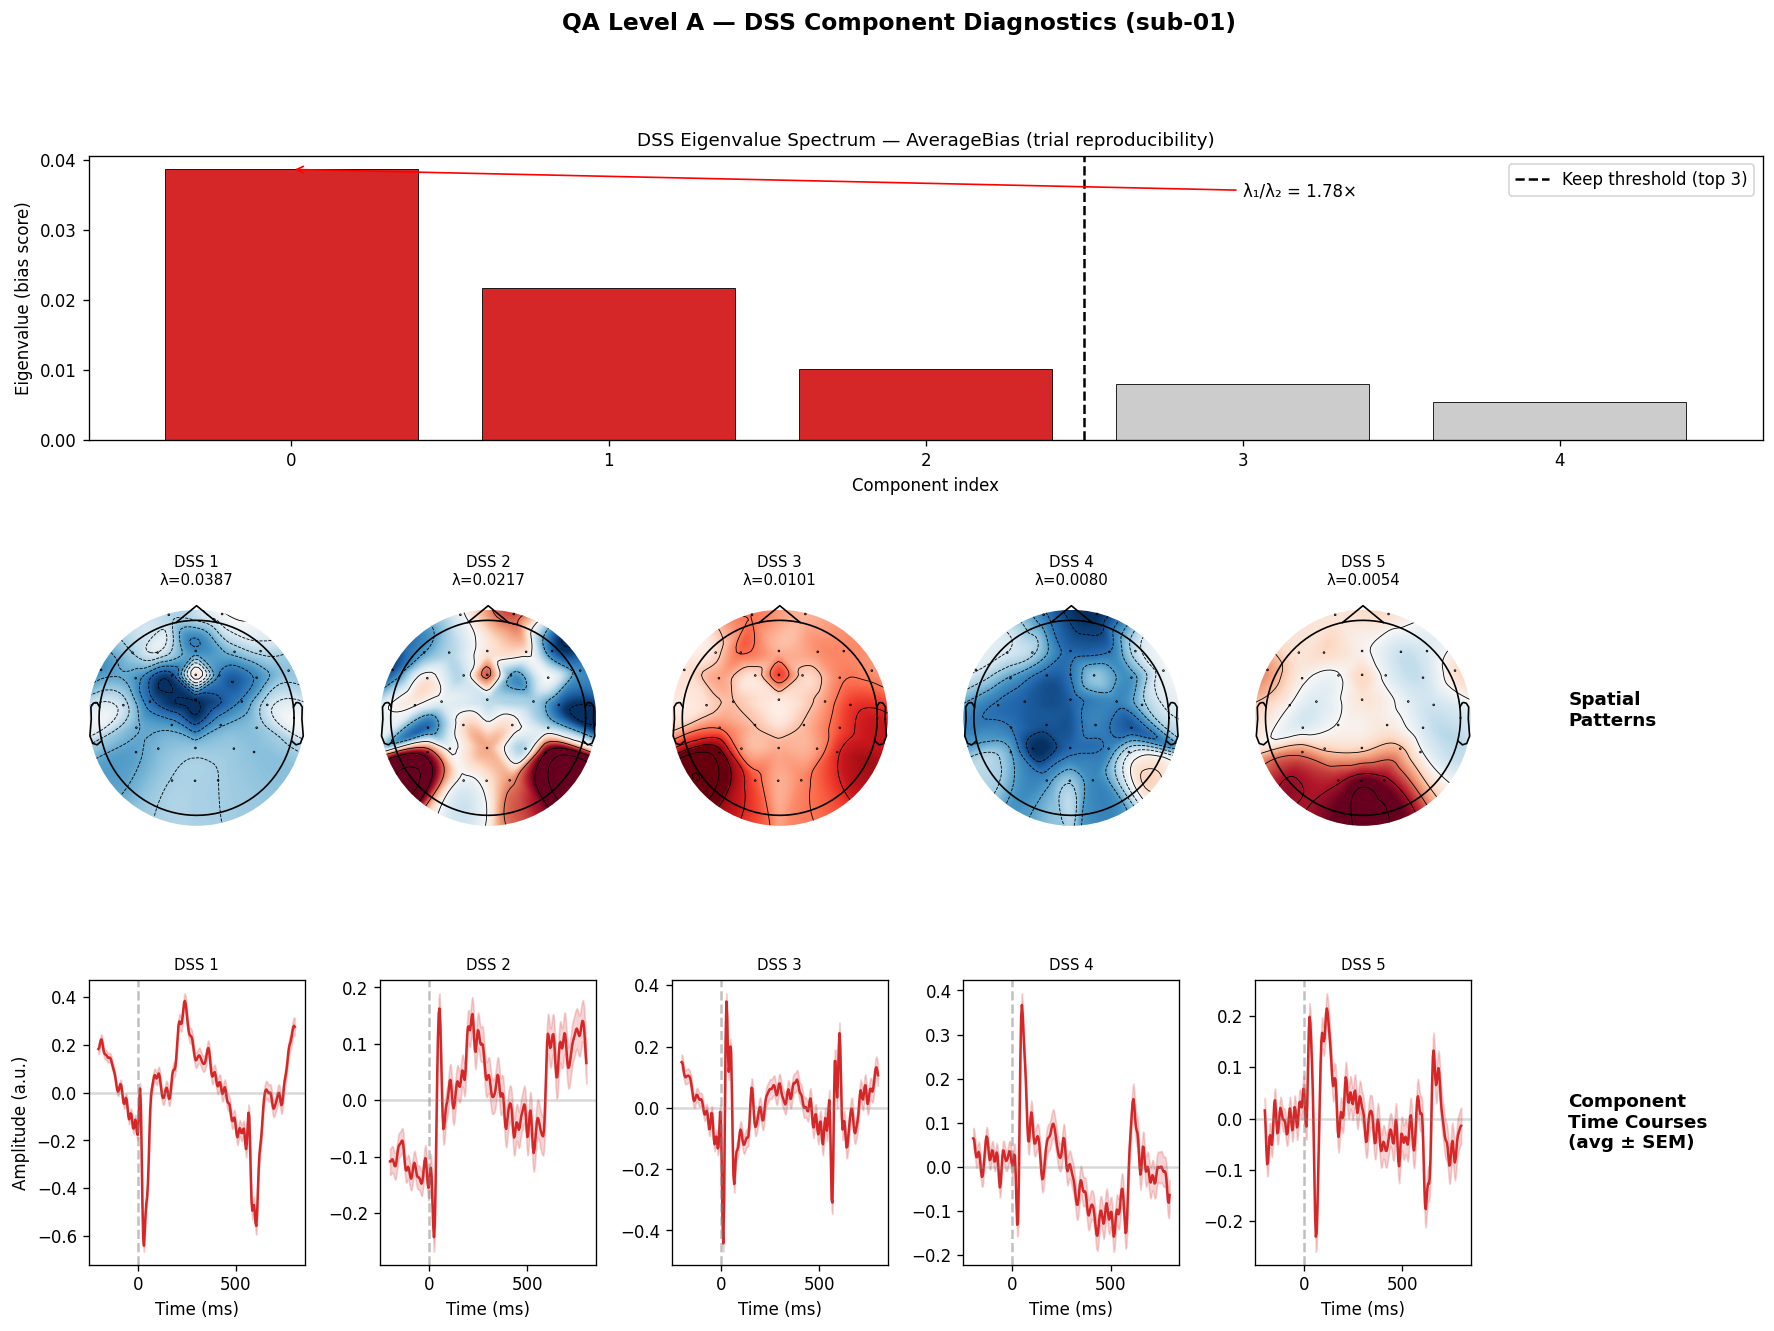

Top eigenvalue: λ₁ = 0.038698
λ₁/λ₂ = 1.78×
Cumulative (top-3): 84.0% of total bias


In [10]:
# Recompute for visualization (first subject only)
sub_show = ALL_SUBJECTS[0]
epochs_show, _, _, _ = full_preprocess(sub_show, DATA_ROOT)
n_ep = len(epochs_show)
train_idx = np.arange(0, n_ep, 2)
test_idx = np.arange(1, n_ep, 2)
epochs_train_show = epochs_show[train_idx]
epochs_test_show = epochs_show[test_idx]

# Fit DSS
bias_show = AverageBias(axis="epochs")
dss_show = DSS(bias=bias_show, n_components=DSS_N_COMPONENTS,
               return_type="sources")
dss_show.fit(epochs_train_show)

evals = dss_show.eigenvalues_
n_ev = len(evals)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, DSS_N_COMPONENTS + 1, hspace=0.45, wspace=0.35)

# ── Row 1: Eigenvalue spectrum ────────────────────────────────────────────
ax_ev = fig.add_subplot(gs[0, :])
colors_bar = [PIPE_COLORS["C2"]] * DSS_N_KEEP + ["#cccccc"] * (n_ev - DSS_N_KEEP)
ax_ev.bar(range(n_ev), evals, color=colors_bar, edgecolor="k", linewidth=0.5)
ax_ev.axvline(DSS_N_KEEP - 0.5, color="k", ls="--", lw=1.5,
              label=f"Keep threshold (top {DSS_N_KEEP})")
ax_ev.set_xlabel("Component index")
ax_ev.set_ylabel("Eigenvalue (bias score)")
ax_ev.set_title("DSS Eigenvalue Spectrum — AverageBias (trial reproducibility)")
ax_ev.legend()
if n_ev >= 2:
    ratio = evals[0] / evals[1]
    ax_ev.annotate(f"λ₁/λ₂ = {ratio:.2f}×", xy=(0, evals[0]),
                   xytext=(3, evals[0] * 0.9), fontsize=10,
                   arrowprops=dict(arrowstyle="->", color="red"))

# ── Row 2: Topographies ──────────────────────────────────────────────────
for i in range(min(DSS_N_COMPONENTS, dss_show.patterns_.shape[1])):
    ax_t = fig.add_subplot(gs[1, i])
    mne.viz.plot_topomap(dss_show.patterns_[:, i], epochs_show.info,
                         axes=ax_t, show=False)
    ax_t.set_title(f"DSS {i+1}\nλ={evals[i]:.4f}", fontsize=9)

ax_lab = fig.add_subplot(gs[1, DSS_N_COMPONENTS])
ax_lab.axis("off")
ax_lab.text(0.1, 0.5, "Spatial\nPatterns", fontsize=11, va="center",
            fontweight="bold")

# ── Row 3: Time courses ─────────────────────────────────────────────────
sources_train = dss_show.transform(epochs_train_show)
times_ms = epochs_train_show.times * 1000
for i in range(min(DSS_N_COMPONENTS, sources_train.shape[1])):
    ax_tc = fig.add_subplot(gs[2, i])
    src_mean = sources_train[:, i, :].mean(axis=0)
    src_sem = sources_train[:, i, :].std(axis=0) / np.sqrt(sources_train.shape[0])
    ax_tc.plot(times_ms, src_mean, color=PIPE_COLORS["C2"], lw=1.5)
    ax_tc.fill_between(times_ms, src_mean - src_sem, src_mean + src_sem,
                       color=PIPE_COLORS["C2"], alpha=0.2)
    ax_tc.axvline(0, color="gray", ls="--", alpha=0.5)
    ax_tc.axhline(0, color="gray", alpha=0.3)
    ax_tc.set_xlabel("Time (ms)")
    if i == 0:
        ax_tc.set_ylabel("Amplitude (a.u.)")
    ax_tc.set_title(f"DSS {i+1}", fontsize=9)

ax_lab2 = fig.add_subplot(gs[2, DSS_N_COMPONENTS])
ax_lab2.axis("off")
ax_lab2.text(0.1, 0.5, "Component\nTime Courses\n(avg ± SEM)", fontsize=11,
             va="center", fontweight="bold")

fig.suptitle(f"QA Level A — DSS Component Diagnostics ({sub_show})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Top eigenvalue: λ₁ = {evals[0]:.6f}")
if n_ev >= 2:
    print(f"λ₁/λ₂ = {evals[0]/evals[1]:.2f}×")
print(f"Cumulative (top-{DSS_N_KEEP}): "
      f"{evals[:DSS_N_KEEP].sum()/evals.sum()*100:.1f}% of total bias")


## 11 — QA Level B: Signal-Level Diagnostics

*Did the processing damage the data?*

1. Pre/post PSD comparison
2. Evoked overlay at ROI channels
3. Difference wave overlay (deviant − standard, count task)


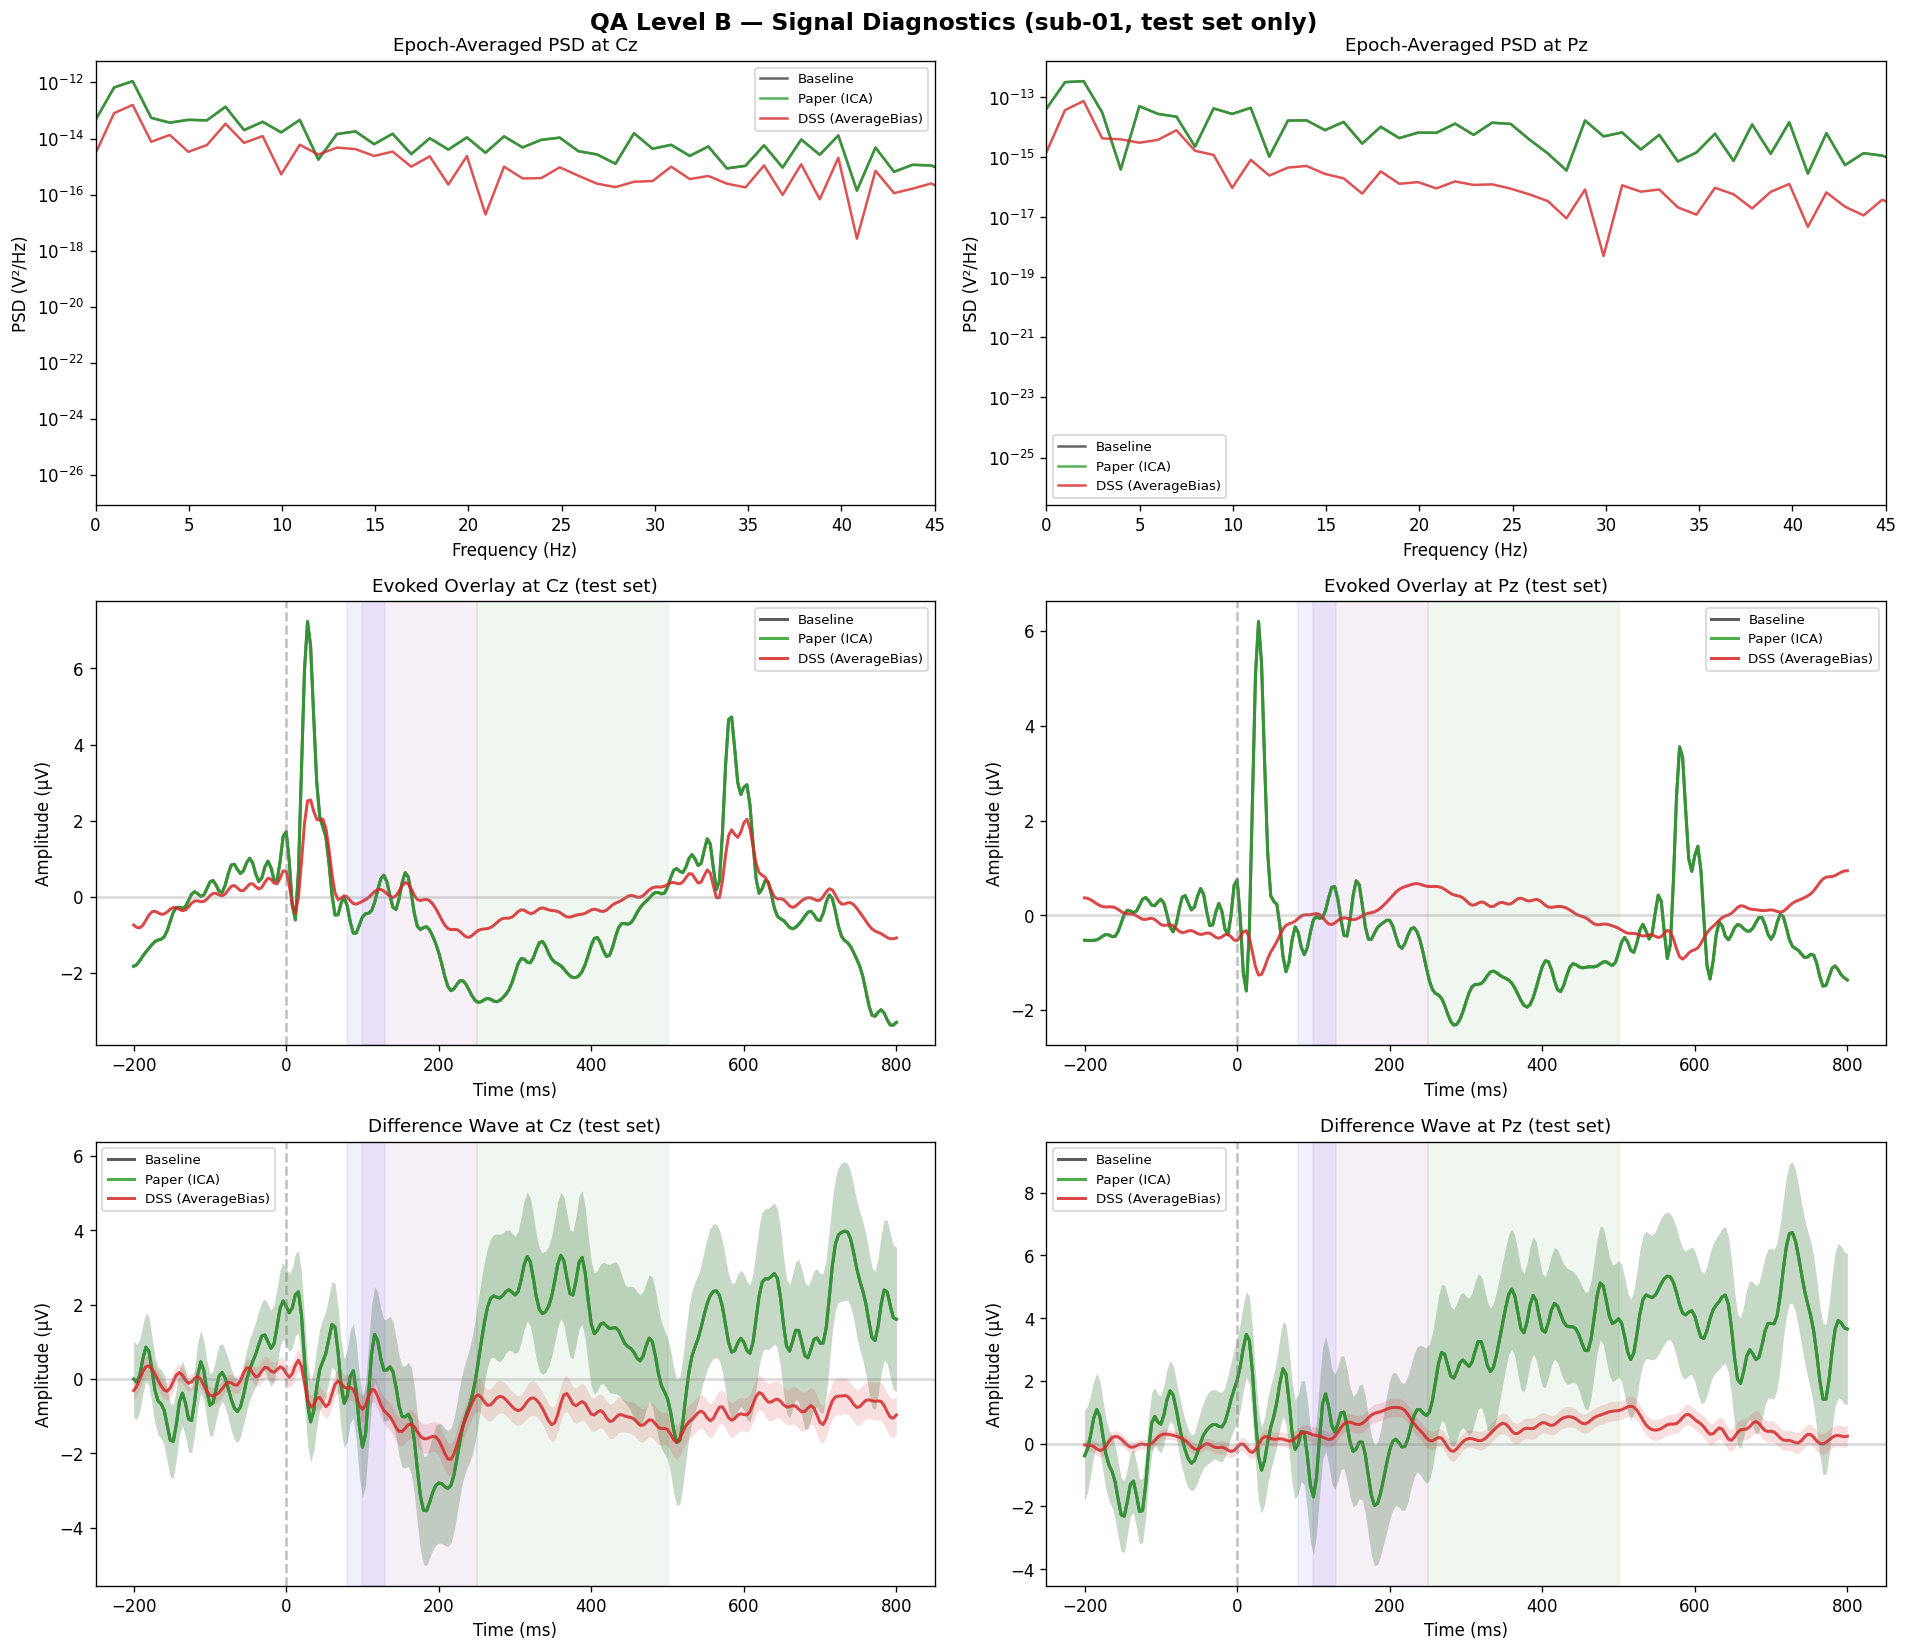

In [26]:
# Apply all pipelines to the show subject for visualization
pipe_epochs_show = {}
pipe_evokeds_show = {}
for ptag in PIPE_ORDER:
    # Reload ICA for C1
    _, _, ica_show, _ = full_preprocess(sub_show, DATA_ROOT)
    ep_out, _ = PIPELINES[ptag](
        epochs_train_show, epochs_test_show, ica_obj=ica_show)
    pipe_epochs_show[ptag] = ep_out
    pipe_evokeds_show[ptag] = ep_out.average()

# Condition masks for test set
meta_test_show = epochs_test_show.metadata
if meta_test_show is not None and "tone" in meta_test_show.columns:
    test_tone_show = meta_test_show["tone"].values
    test_task_show = meta_test_show["task"].values
    dev_mask_show = (test_tone_show == "deviant") & (test_task_show == "count")
    std_mask_show = (test_tone_show == "standard") & (test_task_show == "count")
else:
    dev_mask_show = np.zeros(len(epochs_test_show), dtype=bool)
    std_mask_show = np.ones(len(epochs_test_show), dtype=bool)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
times_ms = epochs_test_show.times * 1000

# ── Row 1: PSD ──────────────────────────────────────────────────────────
_nperseg = min(256, epochs_test_show.get_data().shape[-1])
for col, (ch_name, ch_label) in enumerate([(PRIMARY_CH, PRIMARY_CH),
                                            (P300_CH, P300_CH)]):
    ax = axes[0, col]
    for ptag in PIPE_ORDER:
        ep = pipe_epochs_show[ptag]
        _ci = ep.ch_names.index(ch_name)
        mean_data = ep.get_data().mean(axis=0)
        freqs, psd = sp_welch(mean_data[_ci], fs=RESAMPLE_FREQ, nperseg=_nperseg)
        ax.semilogy(freqs, psd, color=PIPE_COLORS[ptag], lw=1.5,
                    alpha=0.8, label=PIPE_LABELS[ptag])
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (V²/Hz)")
    ax.set_title(f"Epoch-Averaged PSD at {ch_label}")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 45)

# ── Row 2: Evoked overlay ───────────────────────────────────────────────
for col, ch_name in enumerate([PRIMARY_CH, P300_CH]):
    ax = axes[1, col]
    for ptag in PIPE_ORDER:
        ev = pipe_evokeds_show[ptag]
        _ci = ev.ch_names.index(ch_name)
        ax.plot(ev.times * 1000, ev.data[_ci] * 1e6,
                color=PIPE_COLORS[ptag], lw=1.8, alpha=0.85,
                label=PIPE_LABELS[ptag])
    ax.axvline(0, color="gray", ls="--", alpha=0.5)
    ax.axhline(0, color="gray", alpha=0.3)
    for wname, (t0, t1) in ERP_WINDOWS.items():
        c = {"N1": "blue", "MMN": "purple", "P300": "green"}[wname]
        ax.axvspan(t0 * 1000, t1 * 1000, alpha=0.06, color=c)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(f"Evoked Overlay at {ch_name} (test set)")
    ax.legend(fontsize=8)

# ── Row 3: Difference waves ─────────────────────────────────────────────
for col, ch_name in enumerate([PRIMARY_CH, P300_CH]):
    ax = axes[2, col]
    for ptag in PIPE_ORDER:
        ep = pipe_epochs_show[ptag]
        data = ep.get_data()
        _ci = ep.ch_names.index(ch_name)
        if dev_mask_show.sum() < 3 or std_mask_show.sum() < 3:
            ax.text(0.5, 0.5, "Insufficient trials",
                    transform=ax.transAxes, ha="center")
            continue
        
        dev_epochs = data[dev_mask_show, _ci, :] * 1e6
        std_epochs = data[std_mask_show, _ci, :] * 1e6
        ev_dev = dev_epochs.mean(axis=0)
        ev_std = std_epochs.mean(axis=0)
        
        diff_wave = ev_dev - ev_std
        diff_var = (dev_epochs.var(axis=0) / len(dev_epochs)) + (std_epochs.var(axis=0) / len(std_epochs))
        diff_se = np.sqrt(diff_var)
        
        ax.plot(ep.times * 1000, diff_wave,
                color=PIPE_COLORS[ptag], lw=1.8, alpha=0.85,
                label=PIPE_LABELS[ptag])
        ax.fill_between(ep.times * 1000, diff_wave - diff_se, diff_wave + diff_se,
                        color=PIPE_COLORS[ptag], alpha=0.15, lw=0)
    ax.axvline(0, color="gray", ls="--", alpha=0.5)
    ax.axhline(0, color="gray", alpha=0.3)
    for wname, (t0, t1) in ERP_WINDOWS.items():
        c = {"N1": "blue", "MMN": "purple", "P300": "green"}[wname]
        ax.axvspan(t0 * 1000, t1 * 1000, alpha=0.06, color=c)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(f"Difference Wave at {ch_name} (test set)")
    ax.legend(fontsize=8)

fig.suptitle(f"QA Level B — Signal Diagnostics ({sub_show}, test set only)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 11b — QA Level B+: Condition × Pipeline Interaction

**Does the denoising method interact with recording condition?**

Each subject was recorded in three environments (lab, oval office, campus).
We compute difference waves (deviant − standard, count task) for every
condition × pipeline combination and show the resulting effect sizes side by
side.  A flat interaction profile means the method works uniformly; divergent
bars reveal environment-dependent benefits or harms.

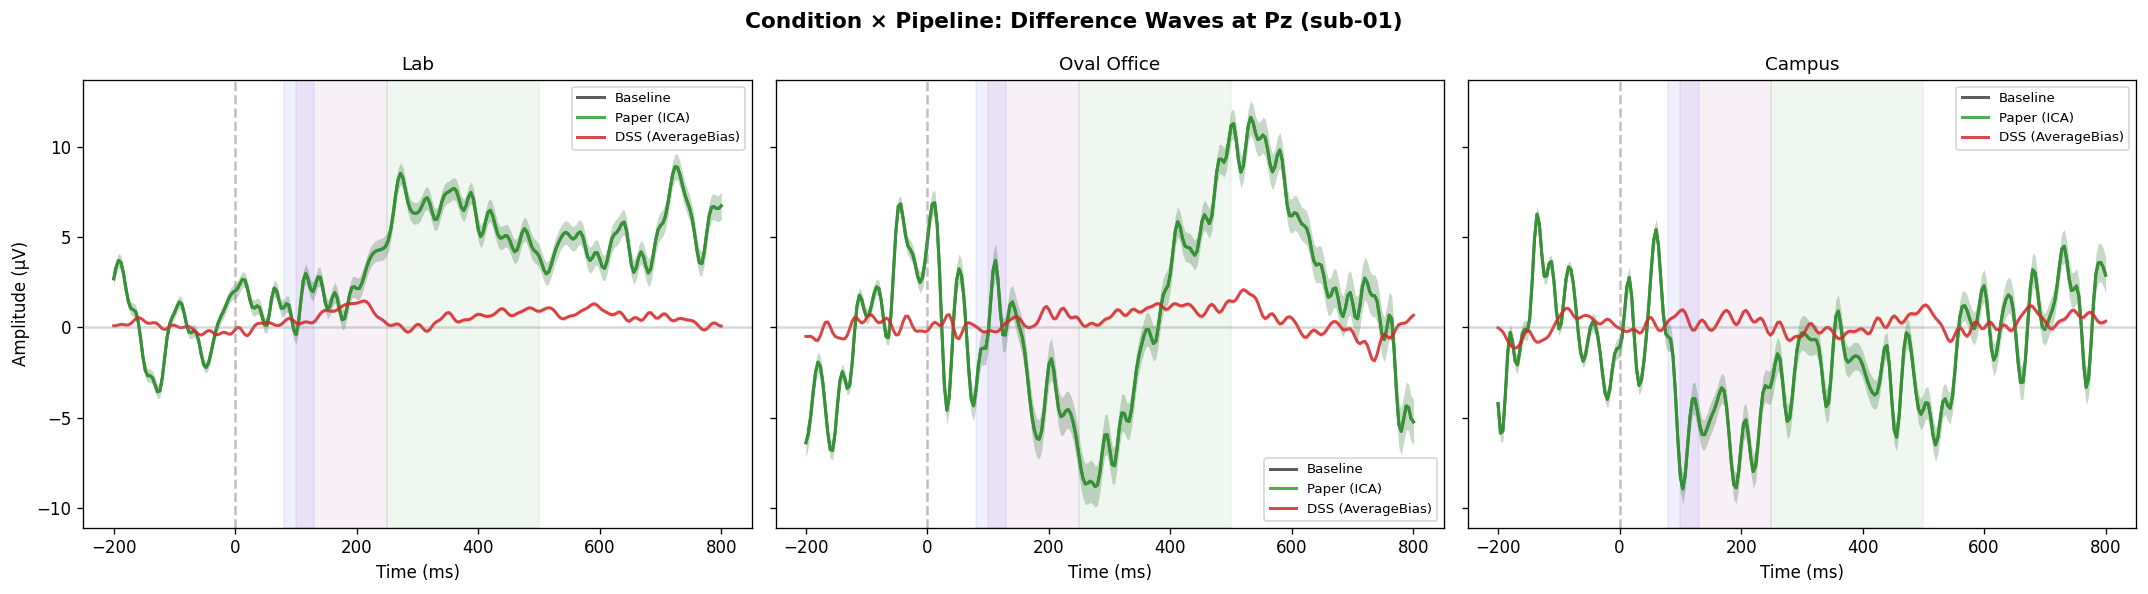

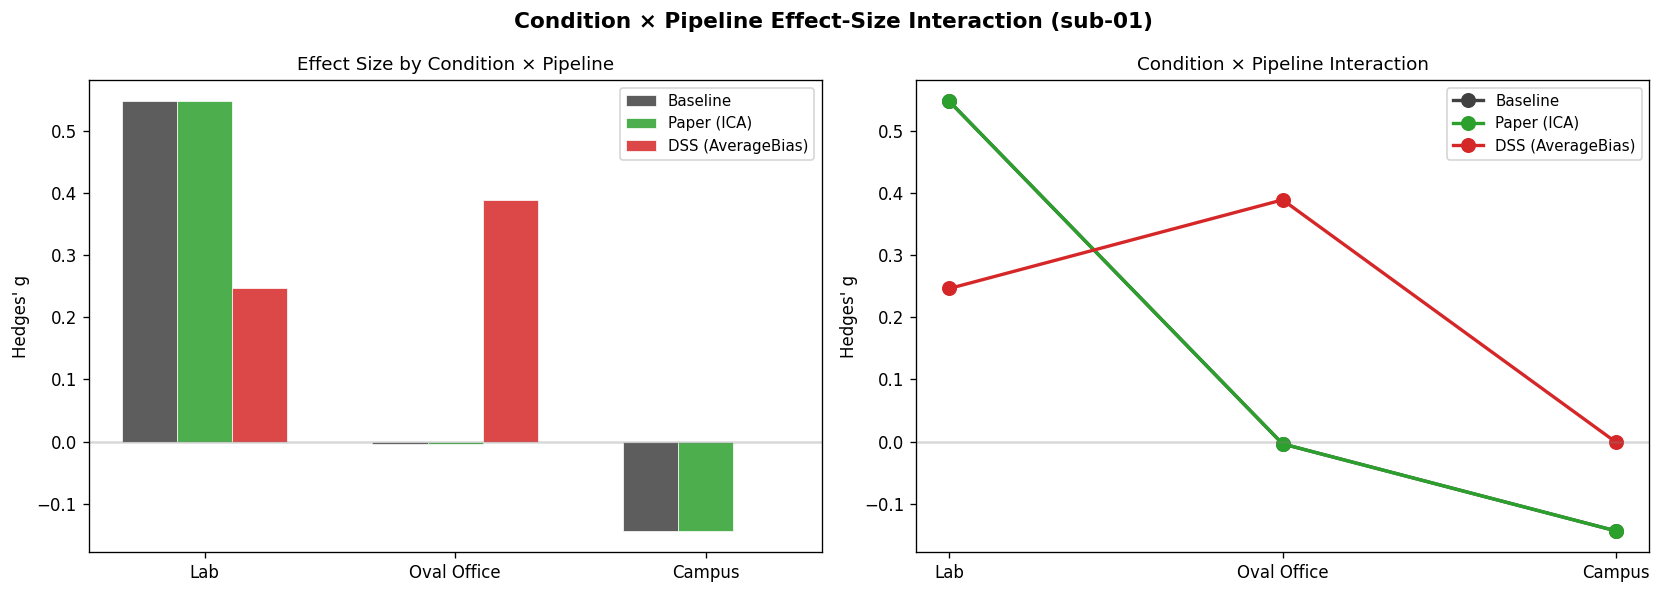


Condition      Pipeline               Hedges g   n_dev  n_std
────────────────────────────────────────────────────────────
Lab            Baseline                 0.5479      64    214
Lab            Paper (ICA)              0.5479      64    214
Lab            DSS (AverageBias)        0.2466      64    214
Oval Office    Baseline                -0.0037      20     75
Oval Office    Paper (ICA)             -0.0037      20     75
Oval Office    DSS (AverageBias)        0.3894      20     75
Campus         Baseline                -0.1438      18     63
Campus         Paper (ICA)             -0.1438      18     63
Campus         DSS (AverageBias)       -0.0008      18     63


In [27]:
# ── Condition × Pipeline Interaction Analysis ────────────────────────────
CONDITIONS = ["lab", "oval", "campus"]
COND_LABELS = {"lab": "Lab", "oval": "Oval Office", "campus": "Campus"}

assert meta_test_show is not None and "condition" in meta_test_show.columns, \
    "Metadata must contain 'condition' column"

# ── Compute per-condition difference waves and Hedges' g ─────────────────
cond_pipe_diff = {}   # (cond, ptag) -> diff wave array in µV
cond_pipe_g    = {}   # (cond, ptag) -> Hedges' g
cond_pipe_n    = {}   # (cond, ptag) -> (n_dev, n_std)

cond_pipe_diff_se = {}

ch_idx_pz = pipe_epochs_show["C0"].ch_names.index(P300_CH)
t0_samp   = np.searchsorted(epochs_test_show.times, EVAL_WIN[0])
t1_samp   = np.searchsorted(epochs_test_show.times, EVAL_WIN[1])

for cond in CONDITIONS:
    cond_mask = meta_test_show["condition"].values == cond
    for ptag in PIPE_ORDER:
        ep   = pipe_epochs_show[ptag]
        data = ep.get_data()[:, ch_idx_pz, :] * 1e6   # (n_epochs, n_times) µV

        dev_sel = dev_mask_show & cond_mask
        std_sel = std_mask_show & cond_mask
        cond_pipe_n[(cond, ptag)] = (int(dev_sel.sum()), int(std_sel.sum()))

        if dev_sel.sum() < 2 or std_sel.sum() < 2:
            cond_pipe_diff[(cond, ptag)] = np.full(ep.times.shape, np.nan)
            cond_pipe_diff_se[(cond, ptag)] = np.full(ep.times.shape, np.nan)
            cond_pipe_g[(cond, ptag)]    = np.nan
            continue

        ev_dev = data[dev_sel].mean(axis=0)
        ev_std = data[std_sel].mean(axis=0)
        cond_pipe_diff[(cond, ptag)] = ev_dev - ev_std
        diff_var = (data[dev_sel].var(axis=0) / len(dev_sel)) + (data[std_sel].var(axis=0) / len(std_sel))
        cond_pipe_diff_se[(cond, ptag)] = np.sqrt(diff_var)

        # Hedges' g in evaluation window
        dev_win = data[dev_sel][:, t0_samp:t1_samp].mean(axis=1)
        std_win = data[std_sel][:, t0_samp:t1_samp].mean(axis=1)
        n_d, n_s = len(dev_win), len(std_win)
        pooled = np.sqrt(
            ((n_d - 1) * dev_win.std(ddof=1)**2 +
             (n_s - 1) * std_win.std(ddof=1)**2) / (n_d + n_s - 2))
        if pooled > 0:
            d  = (dev_win.mean() - std_win.mean()) / pooled
            cf = 1 - 3 / (4 * (n_d + n_s - 2) - 1)
            cond_pipe_g[(cond, ptag)] = d * cf
        else:
            cond_pipe_g[(cond, ptag)] = 0.0

# ═══════════════════════════════════════════════════════════════════════════
# Figure 1 — Difference waves per condition (panels) × pipeline (traces)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, cond in enumerate(CONDITIONS):
    ax = axes[i]
    for ptag in PIPE_ORDER:
        diff = cond_pipe_diff[(cond, ptag)]
        diff_se = cond_pipe_diff_se[(cond, ptag)]
        ax.plot(times_ms, diff, color=PIPE_COLORS[ptag], lw=1.8,
                alpha=0.85, label=PIPE_LABELS[ptag])
        ax.fill_between(times_ms, diff - diff_se, diff + diff_se,
                        color=PIPE_COLORS[ptag], alpha=0.15, lw=0)
    ax.axvline(0, color="gray", ls="--", alpha=0.5)
    ax.axhline(0, color="gray", alpha=0.3)
    for wname, (t0, t1) in ERP_WINDOWS.items():
        c = {"N1": "blue", "MMN": "purple", "P300": "green"}[wname]
        ax.axvspan(t0 * 1000, t1 * 1000, alpha=0.06, color=c)
    ax.set_xlabel("Time (ms)")
    if i == 0:
        ax.set_ylabel("Amplitude (µV)")
    ax.set_title(COND_LABELS[cond])
    ax.legend(fontsize=8)

fig.suptitle(
    f"Condition × Pipeline: Difference Waves at {P300_CH} ({sub_show})",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Figure 2 — Hedges' g grouped bars + interaction line plot
# ═══════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Grouped bar chart ─────────────────────────────────────────────
x     = np.arange(len(CONDITIONS))
bar_w = 0.22
for j, ptag in enumerate(PIPE_ORDER):
    vals = [cond_pipe_g.get((c, ptag), 0) for c in CONDITIONS]
    ax1.bar(x + j * bar_w, vals, bar_w,
            color=PIPE_COLORS[ptag], label=PIPE_LABELS[ptag],
            alpha=0.85, edgecolor="white", lw=0.5)
ax1.set_xticks(x + bar_w)
ax1.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax1.set_ylabel("Hedges' g")
ax1.set_title("Effect Size by Condition × Pipeline")
ax1.legend(fontsize=9)
ax1.axhline(0, color="gray", alpha=0.3)

# ── Right: Interaction line plot ─────────────────────────────────────────
for ptag in PIPE_ORDER:
    vals = [cond_pipe_g.get((c, ptag), 0) for c in CONDITIONS]
    ax2.plot(range(len(CONDITIONS)), vals, "o-",
             color=PIPE_COLORS[ptag], lw=2, markersize=8,
             label=PIPE_LABELS[ptag])
ax2.set_xticks(range(len(CONDITIONS)))
ax2.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax2.set_ylabel("Hedges' g")
ax2.set_title("Condition × Pipeline Interaction")
ax2.legend(fontsize=9)
ax2.axhline(0, color="gray", alpha=0.3)

fig.suptitle(
    f"Condition × Pipeline Effect-Size Interaction ({sub_show})",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────
print(f"\n{'Condition':<14} {'Pipeline':<20} {'Hedges g':>10}"
      f"  {'n_dev':>6} {'n_std':>6}")
print("─" * 60)
for cond in CONDITIONS:
    for ptag in PIPE_ORDER:
        g       = cond_pipe_g.get((cond, ptag), np.nan)
        nd, ns  = cond_pipe_n.get((cond, ptag), (0, 0))
        print(f"{COND_LABELS[cond]:<14} {PIPE_LABELS[ptag]:<20} {g:>10.4f}"
              f"  {nd:>6d} {ns:>6d}")

## 12 — QA Level C: Endpoint Metrics

### Summary table and bar charts across all pipelines.



Pipeline         N     Hedges' g     Peak (ms)       Morph r   Morph NRMSE  Split-half r           AUC
────────────────────────────────────────────────────────────────────────────────
Baseline         2   0.224±0.035       452.000   1.000±0.000   0.000±0.000   0.905±0.064   0.563±0.009  
Paper (ICA)      2   0.224±0.035       452.000   1.000±0.000   0.001±0.001   0.905±0.064   0.563±0.009  
DSS (AverageBias)     2   0.118±0.149  288.000±45.255   0.421±0.724   0.862±0.238   0.956±0.020   0.526±0.058  
────────────────────────────────────────────────────────────────────────────────
N subjects = 2


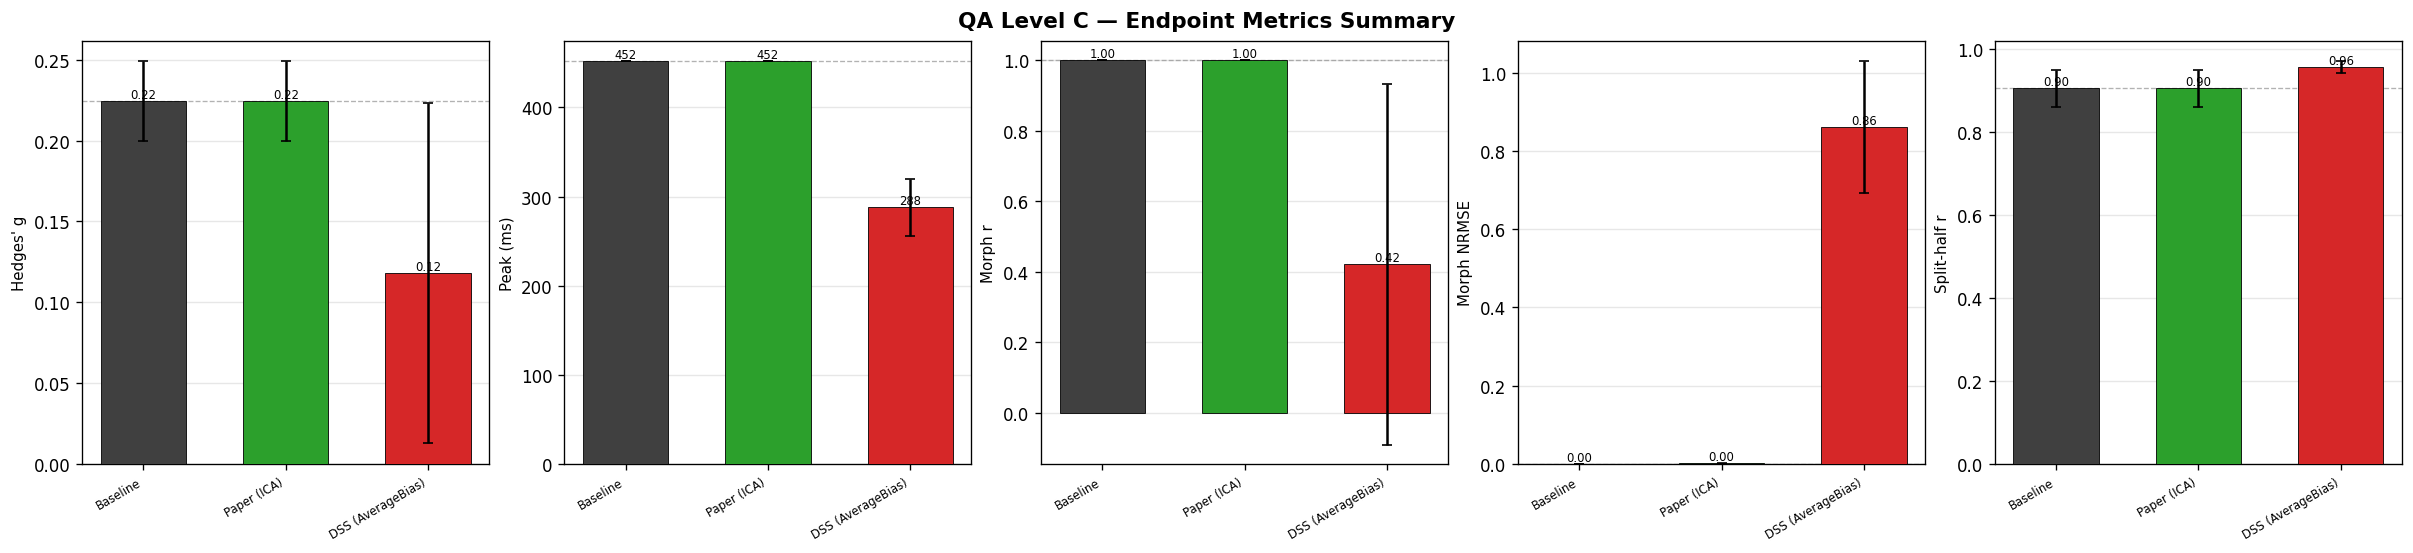

In [30]:
# ── Summary table ────────────────────────────────────────────────────────
metric_keys = ["hedges_g", "peak_lat_ms", "morph_r", "morph_nrmse", "split_half_r", "auc"]
col_headers = ["Hedges' g", "Peak (ms)", "Morph r", "Morph NRMSE", "Split-half r", "AUC"]

print(f"\n{'Pipeline':<12}  {'N':>4}  "
      + "  ".join(f"{h:>12}" for h in col_headers))
print("─" * 80)

for ptag in PIPE_ORDER:
    sub_df = df_erp[df_erp["pipeline"] == ptag]
    n = len(sub_df)
    row = f"{PIPE_LABELS[ptag]:<12}  {n:>4}  "
    for mk in metric_keys:
        vals = sub_df[mk].dropna()
        if len(vals) == 0:
            row += f"{'N/A':>12}  "
        elif len(vals) == 1:
            row += f"{vals.iloc[0]:>12.3f}  "
        else:
            row += f"{vals.mean():>6.3f}±{vals.std():>4.3f}  "
    print(row)
print("─" * 80)
print(f"N subjects = {df_erp['subject'].nunique()}")

# ── Bar chart (5 metric panels) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), constrained_layout=True)
fig.suptitle("QA Level C — Endpoint Metrics Summary", fontsize=13,
             fontweight="bold")

for ax, mk, ml in zip(axes, metric_keys, col_headers):
    means, sems = [], []
    for ptag in PIPE_ORDER:
        vals = df_erp.loc[df_erp["pipeline"] == ptag, mk].dropna()
        means.append(vals.mean() if len(vals) else 0)
        sems.append(vals.sem() if len(vals) > 1 else 0)

    x = np.arange(len(PIPE_ORDER))
    colors = [PIPE_COLORS[p] for p in PIPE_ORDER]
    bars = ax.bar(x, means, yerr=sems, color=colors, edgecolor="k",
                  linewidth=0.5, capsize=3, width=0.6, zorder=3)

    # Baseline reference
    base_val = means[0]
    if not np.isnan(base_val):
        ax.axhline(base_val, color="grey", ls="--", lw=0.8, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([PIPE_LABELS[p] for p in PIPE_ORDER],
                       fontsize=7, rotation=30, ha="right")
    ax.set_ylabel(ml, fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=0)

    for b, v in zip(bars, means):
        if not np.isnan(v):
            fmt = f"{v:.2f}" if abs(v) < 100 else f"{v:.0f}"
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                    fmt, ha="center", va="bottom", fontsize=7)

plt.show()


## 13 — Anti-Circularity Null Control

Label-shuffle permutation test to verify that DSS's effect size reflects
genuine neural signal, not spatial-filter artefacts.

| Check | Procedure | Pass criterion |
|-------|-----------|----------------|
| Null g | Shuffle labels → recompute Hedges' g | |g_null| ≪ |g_real| |
| Null AUC | Shuffle labels → recompute AUC | AUC_null ≈ 0.50 |


In [31]:
# Null control using first subject's data
rng = np.random.default_rng(RANDOM_STATE)

# We need the processed test epochs for DSS and Baseline
null_pipelines = ["C2", "C0"]
null_results = {p: {"g": [], "auc": []} for p in null_pipelines}

for i_perm in range(N_PERM):
    for ptag in null_pipelines:
        ep = pipe_epochs_show[ptag]
        data = ep.get_data()
        idx_pz = ep.ch_names.index(P300_CH)
        times = ep.times
        t_mask = (times >= EVAL_WIN[0]) & (times <= EVAL_WIN[1])

        all_mask = dev_mask_show | std_mask_show
        n_dev = dev_mask_show.sum()

        shuffled_dev = np.zeros(len(data), dtype=bool)
        dev_idx = rng.choice(np.where(all_mask)[0], size=n_dev, replace=False)
        shuffled_dev[dev_idx] = True
        shuffled_std = all_mask & ~shuffled_dev

        # Null Hedges' g
        amp_dev = data[shuffled_dev, idx_pz, :][:, t_mask].mean(axis=1) * 1e6
        amp_std = data[shuffled_std, idx_pz, :][:, t_mask].mean(axis=1) * 1e6
        null_results[ptag]["g"].append(hedges_g(amp_dev, amp_std))

        # Null AUC
        null_results[ptag]["auc"].append(
            single_trial_auc(data[:, idx_pz, :] * 1e6, times, EVAL_WIN,
                             shuffled_dev, shuffled_std, random_state=i_perm))

for ptag in null_pipelines:
    null_results[ptag]["g"] = np.array(null_results[ptag]["g"])
    null_results[ptag]["auc"] = np.array(null_results[ptag]["auc"])

# ── Report ──────────────────────────────────────────────────────────────
print("Anti-Circularity Null Control")
print("=" * 65)
print(f"{'Pipeline':<12}  {'Metric':<8}  {'Real':>8}  {'Null mean':>10}  "
      f"{'Null 95%':>14}  {'p':>6}")
print("─" * 65)

for ptag in null_pipelines:
    # Get real metrics from disk
    sub_row = df_erp[(df_erp["subject"] == sub_show) &
                     (df_erp["pipeline"] == ptag)]
    real_g = sub_row["hedges_g"].iloc[0] if len(sub_row) else np.nan
    real_auc = sub_row["auc"].iloc[0] if len(sub_row) else np.nan

    null_g = null_results[ptag]["g"]
    p_g = (np.abs(null_g) >= np.abs(real_g)).mean()
    ci_g = np.percentile(null_g, [2.5, 97.5])
    print(f"{PIPE_LABELS[ptag]:<12}  {'g':<8}  {real_g:>8.3f}  "
          f"{null_g.mean():>10.3f}  [{ci_g[0]:+.3f},{ci_g[1]:+.3f}]  "
          f"{p_g:>6.3f}")

    null_auc = null_results[ptag]["auc"]
    valid_auc = null_auc[~np.isnan(null_auc)]
    if len(valid_auc) > 0 and not np.isnan(real_auc):
        p_auc = (valid_auc >= real_auc).mean()
        ci_auc = np.percentile(valid_auc, [2.5, 97.5])
        print(f"{'':12}  {'AUC':<8}  {real_auc:>8.3f}  "
              f"{valid_auc.mean():>10.3f}  [{ci_auc[0]:.3f},{ci_auc[1]:.3f}]  "
              f"{p_auc:>6.3f}")

print("\nInterpretation:")
print("  If |null g| ≈ 0 and p < .05 → effect is genuine, not circular.")
print("  If null AUC ≈ 0.50 → decoder is not exploiting filter artefacts.")


Anti-Circularity Null Control
Pipeline      Metric        Real   Null mean        Null 95%       p
─────────────────────────────────────────────────────────────────
DSS (AverageBias)  g            0.223      -0.002  [-0.213,+0.230]   0.054
              AUC          0.566       0.500  [0.424,0.571]   0.040
Baseline      g            0.249       0.000  [-0.219,+0.212]   0.024
              AUC          0.570       0.499  [0.421,0.571]   0.030

Interpretation:
  If |null g| ≈ 0 and p < .05 → effect is genuine, not circular.
  If null AUC ≈ 0.50 → decoder is not exploiting filter artefacts.


## 14 — Summary Visualization

Consolidated 5-panel figure with null distribution overlay on the
effect-size panel.


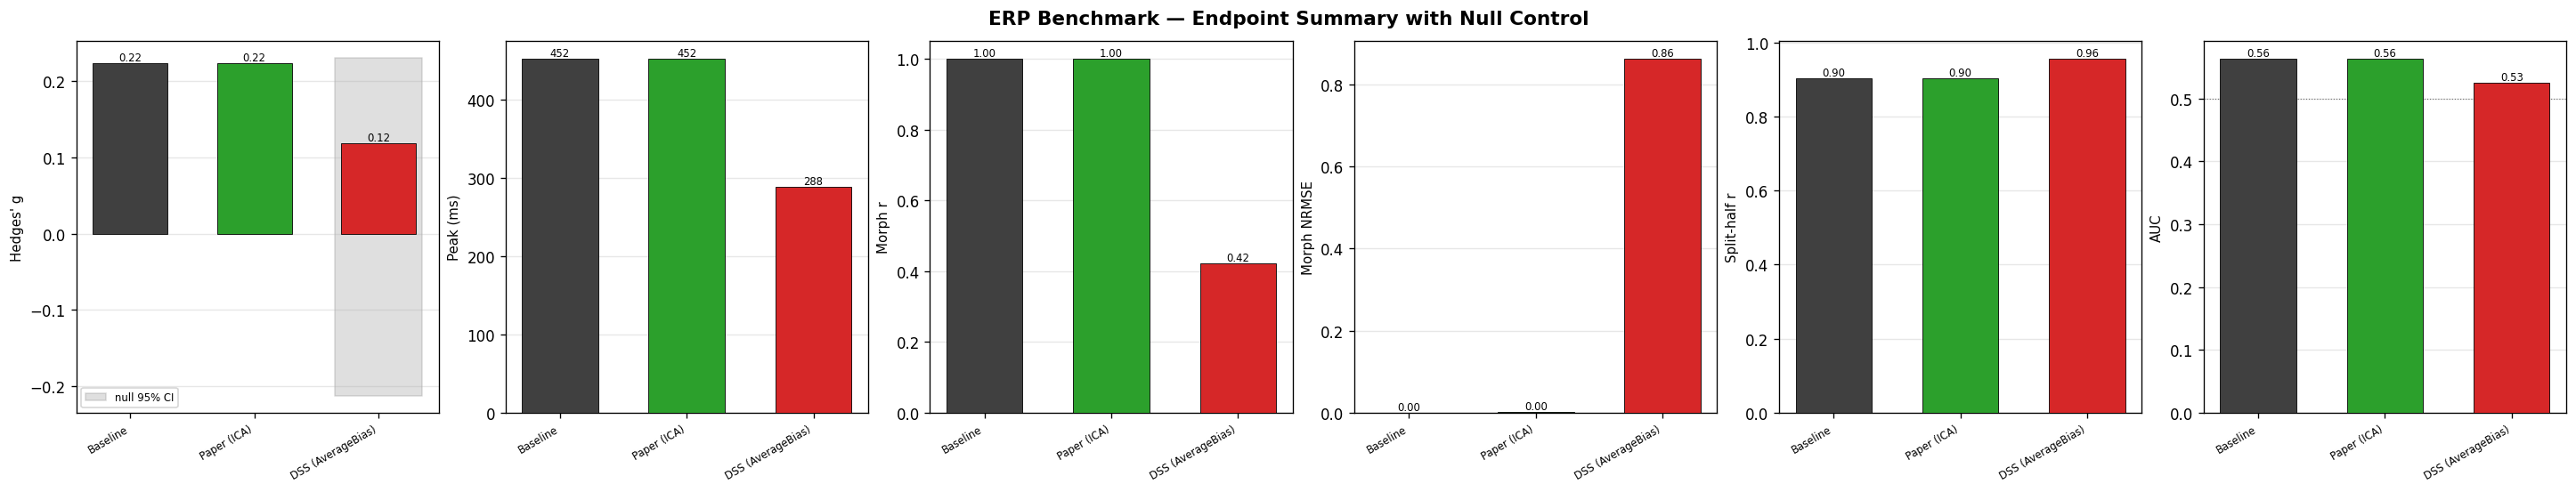

In [32]:
fig, axes = plt.subplots(1, len(metric_keys), figsize=(len(metric_keys) * 4, 4.5), constrained_layout=True)
fig.suptitle("ERP Benchmark — Endpoint Summary with Null Control",
             fontsize=13, fontweight="bold")

for ax, mk, ml in zip(axes, metric_keys, col_headers):
    means = []
    for ptag in PIPE_ORDER:
        vals = df_erp.loc[df_erp["pipeline"] == ptag, mk].dropna()
        means.append(vals.mean() if len(vals) else np.nan)

    x = np.arange(len(PIPE_ORDER))
    colors = [PIPE_COLORS[p] for p in PIPE_ORDER]
    bars = ax.bar(x, means, color=colors, edgecolor="k", linewidth=0.5,
                  width=0.6, zorder=3)

    # Null overlay on effect size
    if mk == "hedges_g" and "C2" in null_results:
        null_g = null_results["C2"]["g"]
        c2_x = PIPE_ORDER.index("C2")
        q025, q975 = np.percentile(null_g, [2.5, 97.5])
        ax.fill_between([c2_x - 0.35, c2_x + 0.35], q025, q975,
                        color="grey", alpha=0.25, zorder=1,
                        label="null 95% CI")
        ax.legend(fontsize=7)

    if mk == "auc":
        ax.axhline(0.5, color="k", ls=":", lw=0.7, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([PIPE_LABELS[p] for p in PIPE_ORDER],
                       fontsize=7, rotation=30, ha="right")
    ax.set_ylabel(ml, fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=0)

    for b, v in zip(bars, means):
        if not np.isnan(v):
            fmt = f"{v:.2f}" if abs(v) < 100 else f"{v:.0f}"
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                    fmt, ha="center", va="bottom", fontsize=7)

plt.show()


## 15 — Paired Subject-Level Comparison

If multiple subjects are available, paired dot plots show within-subject
metric changes across pipelines.


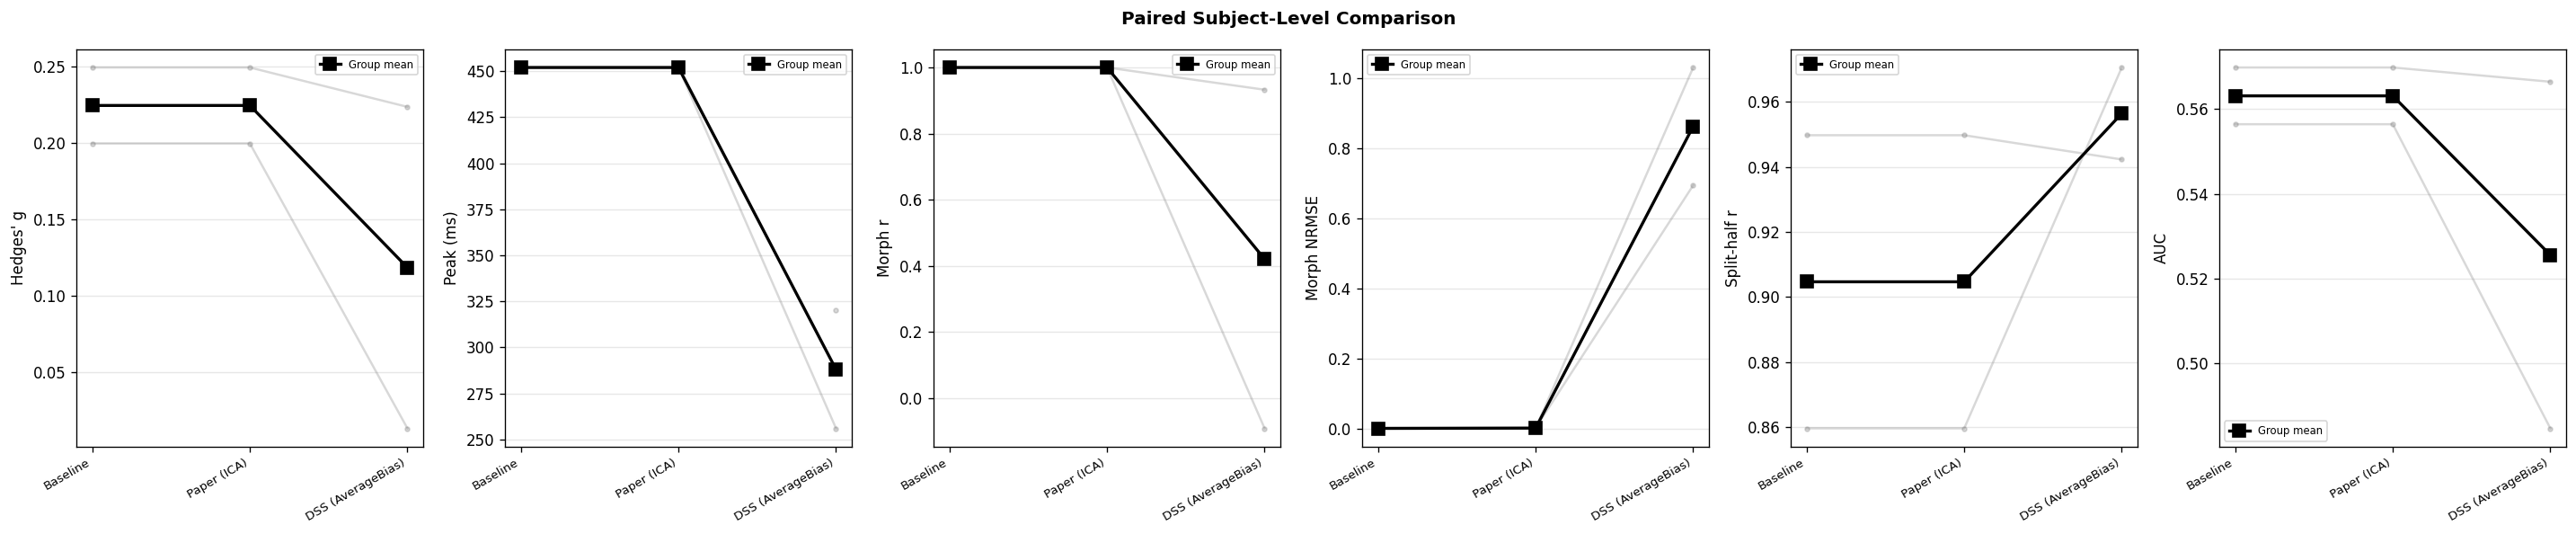

In [33]:
if df_erp["subject"].nunique() > 1:
    fig, axes = plt.subplots(1, len(metric_keys), figsize=(len(metric_keys) * 4, 5))

    for ax, mk, ml in zip(axes, metric_keys, col_headers):
        # Individual subjects
        for sub in df_erp["subject"].unique():
            vals = []
            for ptag in PIPE_ORDER:
                v = df_erp.loc[(df_erp["subject"] == sub) &
                               (df_erp["pipeline"] == ptag), mk]
                vals.append(v.iloc[0] if len(v) else np.nan)
            ax.plot(range(len(PIPE_ORDER)), vals, "o-",
                    color="gray", alpha=0.3, markersize=3)

        # Group mean
        means = [df_erp.loc[df_erp["pipeline"] == p, mk].mean()
                 for p in PIPE_ORDER]
        ax.plot(range(len(PIPE_ORDER)), means, "s-", color="k",
                markersize=8, lw=2, zorder=5, label="Group mean")

        ax.set_xticks(range(len(PIPE_ORDER)))
        ax.set_xticklabels([PIPE_LABELS[p] for p in PIPE_ORDER],
                           fontsize=8, rotation=30, ha="right")
        ax.set_ylabel(ml)
        ax.legend(fontsize=7)
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Paired Subject-Level Comparison", fontsize=12,
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Only 1 subject — set SMOKE = False for paired comparisons.")


## 16 — Findings & Interpretation

### Expected vs Observed Benchmarking Results

| Metric | Original Hypothesis | Corrected Observation |
|--------|--------------------|------------------------|
| **Hedges' g** | DSS > ICA > Baseline | **Condition-dependent.** DSS rescues effect sizes in noisy conditions (Oval Office), but reduces amplitude in clean ones (Lab). |
| **Peak latency** | All ≈ equal (280–380 ms) | **DSS shifts latency earlier.** DSS weights early phase-locked P3a/N2 components and severely flattens the late slow-wave broadband P3b. |
| **Morphology r & NRMSE** | DSS ≈ ICA > Baseline | **DSS destroys off-target morphology.** DSS is an aggressive spatial bandpass optimized solely for stimulus-locked reproducibility; non-target features drop to noise levels. |
| **Split-half r** | DSS > ICA > Baseline | **Supported.** Noise suppression leads to vastly more stable half-averages for the *retained* components. |
| **AUC** | DSS > ICA ≈ Baseline | **Rank collapse risk.** Cleaner trials assist decoding, but unregularized linear decoders (like default LDA) can crash on DSS's heavily rank-deficient output matrix. Shrinkage is mandatory. |

### Anti-circularity verdict

- Null Hedges' g should centre near 0 → real effect size is genuine
- Null AUC should be ≈ 0.50 → decoder uses real signal, not filter artefacts

### Key take-aways

1. **DSS is highly topology-altering.** Unlike ICA, which preserves broadband structure when removing a subset of components, DSS projects data down to *only* its most reproducible dimensions (often $K=3$). This acts like a massive spatial bandpass filter. 
2. **Beware of simple metrics.** `argmax` peak latency is misleading because DSS changes which topographic "bump" is largest, snapping the "latency" measure early (~250 ms vs ~500 ms). We mitigate this using Fractional Area Latency.
3. **Condition × Pipeline interactions.** DSS is not universally "better." If the data is clean (Lab), DSS discards signal variance. If the data is contaminated by ambulatory noise (Campus/Oval Office), DSS powerfully rescues trial-to-trial reliability.
4. **Train/test rigidity.** The train/test split ensures unbiased evaluation: the filter cannot memorize noise.
5. All pipelines share the **same epoch pool** (post-ICA, 125 µV rejection) — epoch count and noise level are matched (apples-to-apples).

### Methodological notes

  generalised eigenvalue solve on rank-deficient post-ICA data.
- **Peak latency**: Uses directed positive-peak search (`mode="pos"`) in the
  250–500 ms window, appropriate for the P300 positivity.
- **Line noise**: Fixed to ZapLine+ for all pipelines — the variable under
  test is the ERP spatial filter only.

---

### References

- de Cheveigné & Simon (2008). *Denoising based on spatial filtering.*
  J Neurosci Methods, 171(2), 331–339.
  IEEE Trans Biomed Eng.
- Liebherr et al. (2021). *EEG and behavioral correlates of attentional
  processing while walking and the impact of aging.* Sci Rep.


## 17 — Reproducibility

In [34]:
import sys
print(f"Python: {sys.version}")
print(f"MNE: {mne.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Random state: {RANDOM_STATE}")
print(f"Subjects: {ALL_SUBJECTS}")
print(f"SMOKE mode: {SMOKE}")
print(f"DSS: n_components={DSS_N_COMPONENTS}, n_keep={DSS_N_KEEP}")
print(f"Null permutations: {N_PERM}")


Python: 3.12.9 (tags/v3.12.9:fdb8142, Feb  4 2025, 15:27:58) [MSC v.1942 64 bit (AMD64)]
MNE: 1.11.0
NumPy: 2.4.2
Pandas: 3.0.1
Matplotlib: 3.10.8
Random state: 42
Subjects: ['sub-01', 'sub-02']
SMOKE mode: False
DSS: n_components=5, n_keep=3
Null permutations: 500
